# Portfolio Analysis of Five Market Leaders (NVDA, GLD, JPM, XOM, SPY)

## Project overview
This notebook evaluates a five-asset portfolio using historical market data from Yahoo Finance. The analysis covers:

- data collection and cleaning
- daily log returns
- annualised return and volatility
- correlation and covariance structure
- Monte Carlo simulation of random portfolios
- portfolio optimisation (minimum variance and maximum Sharpe)
- risk metrics: Value at Risk (VaR), maximum drawdown, and beta versus SPY

## Why these assets?
This portfolio mixes different market exposures:

- **NVDA**: high-growth technology exposure
- **JPM**: large-cap banking exposure
- **XOM**: energy sector exposure
- **SPY**: broad U.S. equity market exposure
- **GLD**: gold ETF exposure for diversification

> Note: GLD and SPY are ETFs rather than individual stocks, so this is better described as a **multi-asset portfolio analysis** rather than a pure stock-only study.


## 1) Import libraries and download data

In [10]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.optimize import minimize

plt.rcParams["figure.figsize"] = (10, 6)

assets = ["NVDA", "GLD", "JPM", "XOM", "SPY"]
start_date = "2021-06-03"
end_date = "2026-03-02"
trading_days = 252
risk_free_rate = 0.02  # 2% annual risk-free rate assumption

raw_data = yf.download(assets, start=start_date, end=end_date, auto_adjust=True, progress=False)

if raw_data.empty:
    raise ValueError("No data was downloaded. Check tickers, internet connection, or date range.")

close_prices = raw_data["Close"].dropna()

print("Downloaded price data shape:", close_prices.shape)
display(close_prices.head())

Downloaded price data shape: (1190, 5)


Ticker,GLD,JPM,NVDA,SPY,XOM
Date,,,,,
2021-06-03,175.270004,147.195602,16.927084,391.124084,51.251408
2021-06-04,177.160004,147.434799,17.534058,394.701172,51.477592
2021-06-07,177.869995,146.743851,17.574703,394.318268,51.142506
2021-06-08,177.320007,146.159195,17.413111,394.402313,52.047241
2021-06-09,176.979996,144.334442,17.318575,393.813965,52.482849


## 2) Compute daily log returns and summary statistics

In [11]:
returns = np.log(close_prices / close_prices.shift(1)).dropna()

annual_returns = returns.mean() * trading_days
annual_volatility = returns.std() * np.sqrt(trading_days)

summary = pd.DataFrame({
    "Annual Return": annual_returns,
    "Annual Volatility": annual_volatility,
    "Sharpe (rf=2%)": (annual_returns - risk_free_rate) / annual_volatility
}).sort_values("Annual Return", ascending=False)

display(summary.round(4))

,Annual Return,Annual Volatility,Sharpe (rf=2%)
Ticker,,,
NVDA,0.4977,0.5194,0.9197
XOM,0.2311,0.2657,0.7945
GLD,0.2152,0.1740,1.1220
JPM,0.1511,0.2458,0.5335
SPY,0.1185,0.1718,0.5735


### Cumulative performance of each asset
This visualization complements the return statistics by showing how $1 invested in each asset evolved over time.

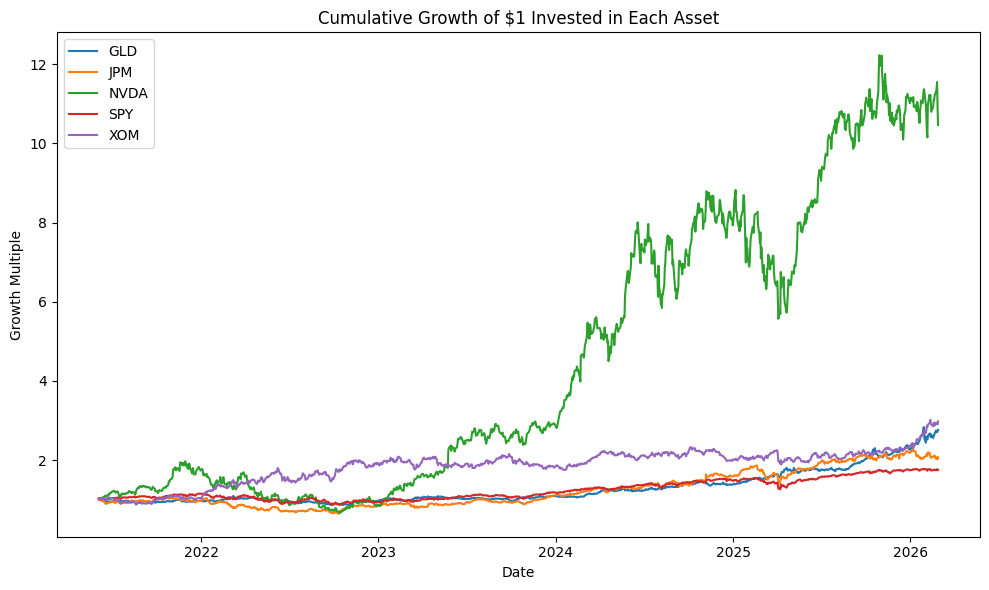

In [12]:
# Cumulative performance of each asset
cumulative_returns = np.exp(returns.cumsum())

plt.figure(figsize=(10, 6))
for col in cumulative_returns.columns:
    plt.plot(cumulative_returns.index, cumulative_returns[col], label=col)

plt.title("Cumulative Growth of $1 Invested in Each Asset")
plt.xlabel("Date")
plt.ylabel("Growth Multiple")
plt.legend()
plt.tight_layout()
plt.savefig("cumulative_returns.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation
At this stage, higher return does **not** automatically mean a better asset. A stronger asset for portfolio construction balances return with volatility and correlation against the rest of the portfolio.


## 3) Correlation and covariance analysis

In [13]:
corr_matrix = returns.corr()
cov_matrix = returns.cov() * trading_days  # annualised covariance matrix

print("Correlation matrix")
display(corr_matrix.round(4))

print("Annualised covariance matrix")
display(cov_matrix.round(4))

Correlation matrix


Ticker,GLD,JPM,NVDA,SPY,XOM
Ticker,,,,,
GLD,1.0000,0.0238,0.0452,0.1043,0.1651
JPM,0.0238,1.0000,0.3322,0.6329,0.3367
NVDA,0.0452,0.3322,1.0000,0.7054,0.0901
SPY,0.1043,0.6329,0.7054,1.0000,0.3361
XOM,0.1651,0.3367,0.0901,0.3361,1.0000


Annualised covariance matrix


Ticker,GLD,JPM,NVDA,SPY,XOM
Ticker,,,,,
GLD,0.0303,0.0010,0.0041,0.0031,0.0076
JPM,0.0010,0.0604,0.0424,0.0267,0.0220
NVDA,0.0041,0.0424,0.2698,0.0629,0.0124
SPY,0.0031,0.0267,0.0629,0.0295,0.0153
XOM,0.0076,0.0220,0.0124,0.0153,0.0706


### Correlation heatmap
This heatmap makes it easier to see which assets move together and which ones may improve diversification.

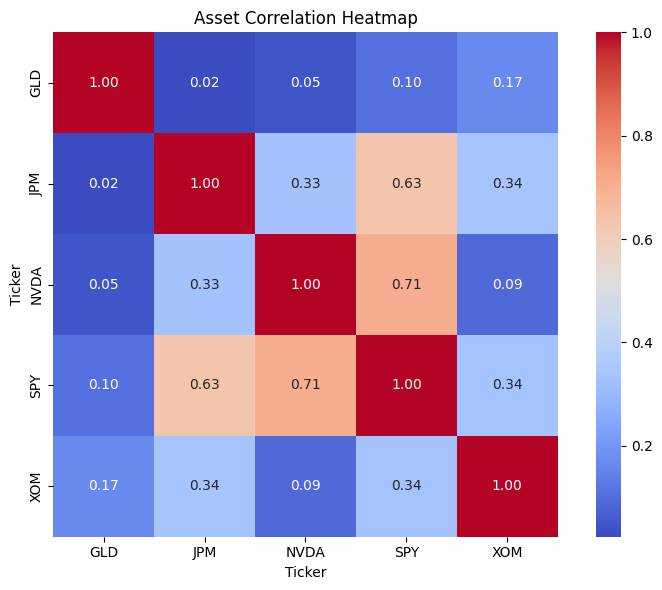

In [14]:
# Correlation heatmap
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Asset Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation
The correlation matrix helps show diversification potential:

- assets with **lower correlation** improve diversification
- **GLD** often behaves differently from equities, which can reduce portfolio risk
- **SPY** captures broad market behaviour, so it tends to move with large U.S. equities such as NVDA and JPM


## 4) Monte Carlo simulation of random portfolios

A common mistake in portfolio notebooks is to annualise the returns twice.  
Here, annual returns are already annualised, so the portfolio return is:

\[
R_p = \sum_i w_i \mu_i
\]

and **not** multiplied by 252 again.


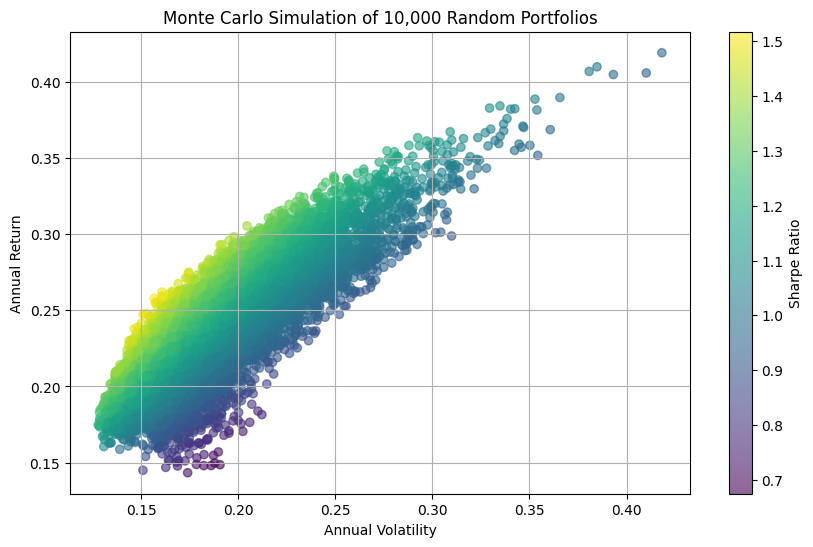

In [15]:
np.random.seed(42)
n_assets = len(assets)
n_portfolios = 10000

results = np.zeros((3, n_portfolios))
weights_record = []

for i in range(n_portfolios):
    weights = np.random.random(n_assets)
    weights /= weights.sum()
    weights_record.append(weights)

    portfolio_return = np.sum(annual_returns.values * weights)
    portfolio_volatility = np.sqrt(weights.T @ cov_matrix.values @ weights)
    portfolio_sharpe = (portfolio_return - risk_free_rate) / portfolio_volatility

    results[0, i] = portfolio_return
    results[1, i] = portfolio_volatility
    results[2, i] = portfolio_sharpe

weights_record = np.array(weights_record)

plt.scatter(results[1, :], results[0, :], c=results[2, :], alpha=0.6)
plt.colorbar(label="Sharpe Ratio")
plt.xlabel("Annual Volatility")
plt.ylabel("Annual Return")
plt.title("Monte Carlo Simulation of 10,000 Random Portfolios")
plt.grid(True)
plt.show()

### Monte Carlo portfolio simulation and efficient frontier
The scatter plot shows simulated portfolios across different risk-return combinations. The red line represents an approximate efficient frontier, while the highlighted points identify the minimum-volatility and maximum-Sharpe portfolios.

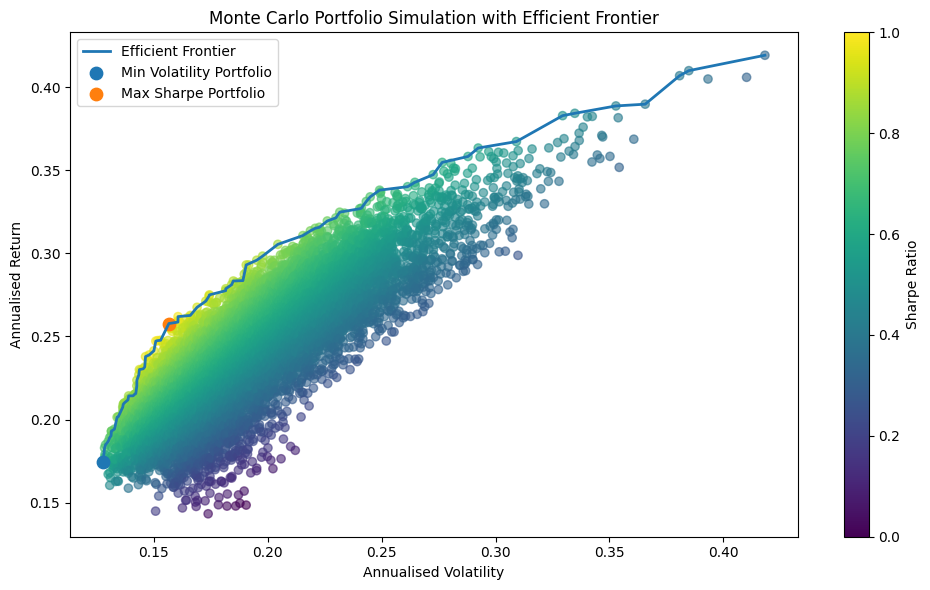

In [16]:
# Monte Carlo portfolio simulation with efficient frontier overlay
import pandas as pd

# Build portfolio DataFrame from simulation results
portfolios = pd.DataFrame({
    "Return": results[0, :],
    "Volatility": results[1, :],
    "Sharpe": results[2, :]
}).sort_values("Volatility")

# Approximate efficient frontier using the upper envelope
frontier = portfolios.loc[portfolios["Return"].cummax() == portfolios["Return"]]

# Identify optimal portfolios
min_vol_idx = portfolios['Volatility'].idxmin()
max_sharpe_idx = portfolios['Sharpe'].idxmax()

min_vol_vol = portfolios.loc[min_vol_idx, 'Volatility']
min_vol_ret = portfolios.loc[min_vol_idx, 'Return']

max_sharpe_vol = portfolios.loc[max_sharpe_idx, 'Volatility']
max_sharpe_ret = portfolios.loc[max_sharpe_idx, 'Return']

plt.figure(figsize=(10, 6))
plt.scatter(
    portfolios["Volatility"],
    portfolios["Return"],
    c=portfolios["Sharpe"],
    cmap="viridis",
    alpha=0.6
)
plt.plot(
    frontier["Volatility"],
    frontier["Return"],
    linewidth=2,
    label="Efficient Frontier"
)
plt.scatter(min_vol_vol, min_vol_ret, s=80, label="Min Volatility Portfolio")
plt.scatter(max_sharpe_vol, max_sharpe_ret, s=80, label="Max Sharpe Portfolio")

plt.colorbar(label="Sharpe Ratio")
plt.xlabel("Annualised Volatility")
plt.ylabel("Annualised Return")
plt.title("Monte Carlo Portfolio Simulation with Efficient Frontier")
plt.legend()
plt.tight_layout()
plt.savefig("efficient_frontier.png", dpi=300, bbox_inches="tight")
plt.show()

## 5) Portfolio optimisation

In [17]:
def portfolio_performance(weights, mean_returns, covariance_matrix):
    portfolio_return = np.sum(mean_returns * weights)
    portfolio_volatility = np.sqrt(weights.T @ covariance_matrix @ weights)
    return portfolio_return, portfolio_volatility

def negative_sharpe_ratio(weights, mean_returns, covariance_matrix, risk_free_rate=0.02):
    p_return, p_volatility = portfolio_performance(weights, mean_returns, covariance_matrix)
    return -((p_return - risk_free_rate) / p_volatility)

def minimum_variance_portfolio(mean_returns, covariance_matrix):
    n = len(mean_returns)
    bounds = tuple((0, 1) for _ in range(n))
    constraints = ({"type": "eq", "fun": lambda x: np.sum(x) - 1},)

    result = minimize(
        fun=lambda w: portfolio_performance(w, mean_returns, covariance_matrix)[1],
        x0=np.array([1 / n] * n),
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )
    return result

def maximum_sharpe_portfolio(mean_returns, covariance_matrix, risk_free_rate=0.02):
    n = len(mean_returns)
    bounds = tuple((0, 1) for _ in range(n))
    constraints = ({"type": "eq", "fun": lambda x: np.sum(x) - 1},)

    result = minimize(
        fun=negative_sharpe_ratio,
        x0=np.array([1 / n] * n),
        args=(mean_returns, covariance_matrix, risk_free_rate),
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )
    return result

min_var_result = minimum_variance_portfolio(annual_returns.values, cov_matrix.values)
max_sharpe_result = maximum_sharpe_portfolio(annual_returns.values, cov_matrix.values, risk_free_rate=risk_free_rate)

min_var_weights = min_var_result.x
max_sharpe_weights = max_sharpe_result.x

min_var_return, min_var_volatility = portfolio_performance(min_var_weights, annual_returns.values, cov_matrix.values)
max_sharpe_return, max_sharpe_volatility = portfolio_performance(max_sharpe_weights, annual_returns.values, cov_matrix.values)

optimised_summary = pd.DataFrame({
    "Portfolio": ["Minimum Variance", "Maximum Sharpe"],
    "Annual Return": [min_var_return, max_sharpe_return],
    "Annual Volatility": [min_var_volatility, max_sharpe_volatility],
    "Sharpe (rf=2%)": [
        (min_var_return - risk_free_rate) / min_var_volatility,
        (max_sharpe_return - risk_free_rate) / max_sharpe_volatility
    ]
})

display(optimised_summary.round(4))

min_var_allocation = pd.Series(min_var_weights, index=assets, name="Minimum Variance Weights")
max_sharpe_allocation = pd.Series(max_sharpe_weights, index=assets, name="Maximum Sharpe Weights")

display(pd.concat([min_var_allocation, max_sharpe_allocation], axis=1).round(4))

,Portfolio,Annual Return,Annual Volatility,Sharpe (rf=2%)
0,Minimum Variance,0.1733,0.1266,1.2113
1,Maximum Sharpe,0.2628,0.1595,1.5223


,Minimum Variance Weights,Maximum Sharpe Weights
NVDA,0.4677,0.5996
GLD,0.0490,0.0262
JPM,0.0000,0.1626
XOM,0.4122,0.0000
SPY,0.0711,0.2117


## 6) Visualise the optimised portfolios against the Monte Carlo cloud

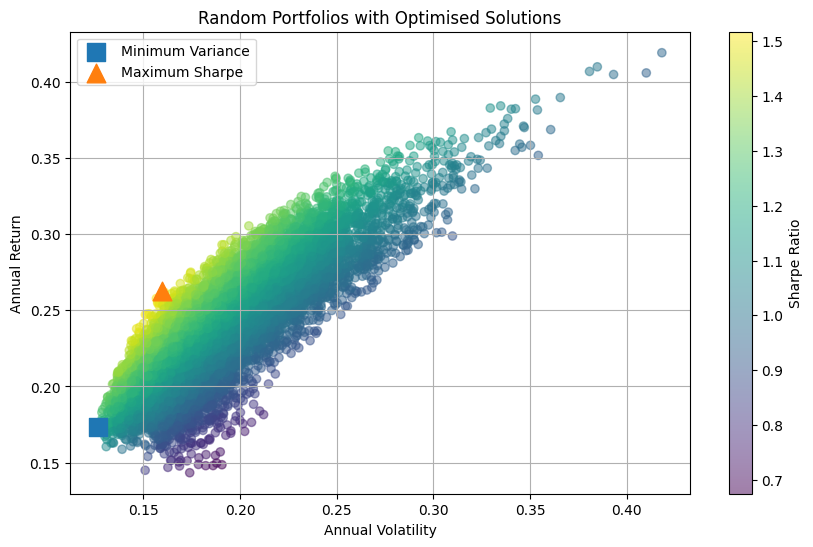

In [18]:
plt.scatter(results[1, :], results[0, :], c=results[2, :], alpha=0.5)
plt.colorbar(label="Sharpe Ratio")
plt.scatter(min_var_volatility, min_var_return, marker="s", s=180, label="Minimum Variance")
plt.scatter(max_sharpe_volatility, max_sharpe_return, marker="^", s=180, label="Maximum Sharpe")
plt.xlabel("Annual Volatility")
plt.ylabel("Annual Return")
plt.title("Random Portfolios with Optimised Solutions")
plt.legend()
plt.grid(True)
plt.show()

## 7) Compare equal-weight, minimum-variance, and maximum-Sharpe portfolios

In [19]:
equal_weights = np.array([1 / n_assets] * n_assets)

comparison_rows = []
for name, weights in {
    "Equal Weight": equal_weights,
    "Minimum Variance": min_var_weights,
    "Maximum Sharpe": max_sharpe_weights
}.items():
    p_return, p_volatility = portfolio_performance(weights, annual_returns.values, cov_matrix.values)
    p_sharpe = (p_return - risk_free_rate) / p_volatility
    comparison_rows.append([name, p_return, p_volatility, p_sharpe])

portfolio_comparison = pd.DataFrame(
    comparison_rows,
    columns=["Portfolio", "Annual Return", "Annual Volatility", "Sharpe (rf=2%)"]
)

display(portfolio_comparison.round(4))

,Portfolio,Annual Return,Annual Volatility,Sharpe (rf=2%)
0,Equal Weight,0.2427,0.1850,1.2037
1,Minimum Variance,0.1733,0.1266,1.2113
2,Maximum Sharpe,0.2628,0.1595,1.5223


## 8) Risk analysis using the maximum-Sharpe portfolio

This section now matches the main optimisation result.  
That avoids the earlier inconsistency where risk metrics were reported for an equal-weight portfolio while optimisation focused on different weights.


In [20]:
selected_weights = max_sharpe_weights
selected_name = "Maximum Sharpe"

portfolio_daily_returns = returns @ selected_weights

# Historical 95% one-day VaR
var_95 = np.percentile(portfolio_daily_returns, 5)

# Maximum drawdown
cumulative_returns = np.exp(portfolio_daily_returns.cumsum())
running_max = cumulative_returns.cummax()
drawdown = (cumulative_returns - running_max) / running_max
max_drawdown = drawdown.min()

# Beta versus SPY
spy_returns = returns["SPY"]
portfolio_excess = portfolio_daily_returns - (risk_free_rate / trading_days)
spy_excess = spy_returns - (risk_free_rate / trading_days)
beta_vs_spy = np.cov(portfolio_excess, spy_excess)[0, 1] / np.var(spy_excess)

risk_metrics = pd.DataFrame({
    "Metric": ["95% 1-Day VaR", "Maximum Drawdown", "Beta vs SPY"],
    "Value": [var_95, max_drawdown, beta_vs_spy]
})

display(risk_metrics)

print(f"{selected_name} portfolio 95% 1-day VaR: {var_95:.2%}")
print(f"{selected_name} portfolio maximum drawdown: {max_drawdown:.2%}")
print(f"{selected_name} portfolio beta vs SPY: {beta_vs_spy:.2f}")

,Metric,Value
0,95% 1-Day VaR,-0.014835
1,Maximum Drawdown,-0.222214
2,Beta vs SPY,0.544380


Maximum Sharpe portfolio 95% 1-day VaR: -1.48%
Maximum Sharpe portfolio maximum drawdown: -22.22%
Maximum Sharpe portfolio beta vs SPY: 0.54


## 9) Allocation charts

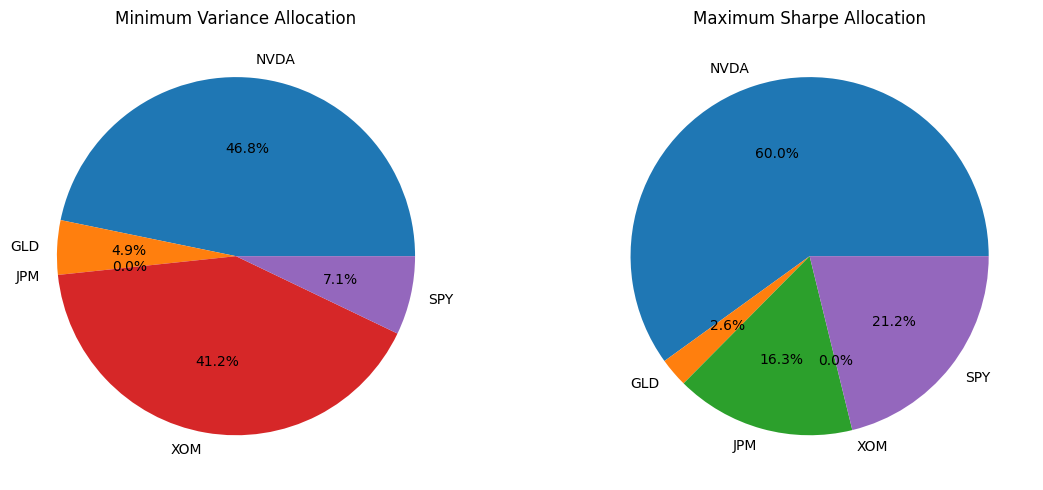

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(min_var_weights, labels=assets, autopct="%1.1f%%")
axes[0].set_title("Minimum Variance Allocation")

axes[1].pie(max_sharpe_weights, labels=assets, autopct="%1.1f%%")
axes[1].set_title("Maximum Sharpe Allocation")

plt.tight_layout()
plt.show()

## 10) Final interpretation

### Main findings
- The portfolio shows how combining **technology, banking, energy, gold, and broad-market exposure** can reduce concentration risk relative to holding a single asset.
- **NVDA** may deliver strong returns, but it also tends to carry high volatility.
- **GLD** can improve diversification because it often behaves differently from equities.
- The **minimum-variance portfolio** prioritises stability over return.
- The **maximum-Sharpe portfolio** seeks the best risk-adjusted outcome under the no-short-selling constraint.

### Important caveats
- Results depend on the chosen sample period.
- Past performance does not guarantee future returns.
- The optimisation assumes historical mean returns and covariance remain informative going forward.
- The chosen risk-free rate is fixed at **2%** for simplicity.

### Conclusion
This analysis suggests that a diversified multi-asset portfolio can produce a better risk-return trade-off than a simple equal-weight allocation. The strongest portfolio choice depends on investor goals:

- risk-averse investors may prefer the **minimum-variance portfolio**
- return-seeking investors focused on risk-adjusted efficiency may prefer the **maximum-Sharpe portfolio**
